# 0-) IMPORTS

In [2]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
from collections import defaultdict
from pathlib import Path

In [3]:
gpus = tf.config.list_physical_devices('GPU')

tf.config.set_visible_devices(gpus[0], 'GPU')

from tensorflow.python.client import device_lib
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')), "\n")

# Tüm cihazları listele ve her cihazın türünü yazdır
local_devices = device_lib.list_local_devices()

for device in local_devices:
    print(f"Device Name: {device.name}")
    print(f"Device Type: {device.device_type}")
    print(f"Device Description: {device.physical_device_desc}")
    print("-" * 40)

TensorFlow Version: 2.10.0
Num GPUs Available:  2 

Device Name: /device:CPU:0
Device Type: CPU
Device Description: 
----------------------------------------
Device Name: /device:GPU:0
Device Type: GPU
Device Description: device: 0, name: DML, pci bus id: <undefined>
----------------------------------------
Device Name: /device:GPU:1
Device Type: GPU
Device Description: device: 1, name: DML, pci bus id: <undefined>
----------------------------------------


# 1-)Data Preprocessing

In [4]:
def plot_images(images, bboxes, class_names, n=5):
    plt.figure(figsize=(20, 10))
    for i in range(min(n, len(images))):
        img = images[i].copy()
        
        # Ensure image is in valid format
        if img.dtype != np.uint8:
            img = img.astype(np.uint8)
            
        # Convert grayscale to BGR if needed
        if len(img.shape) == 2 or img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            
        # Ensure color conversion safety
        try:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        except cv2.error:
            print(f"Invalid image at index {i} - shape: {img.shape}, dtype: {img.dtype}")
            continue
            
        # Draw bounding boxes
        for (class_id, xmin, ymin, xmax, ymax) in bboxes[i]:
            color = (0,255,0) if class_id == 0 else (0,0,255)
            # Convert coordinates to integers
            xmin, ymin, xmax, ymax = map(int, (xmin, ymin, xmax, ymax))
            cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), color, 2)
            cv2.putText(img_rgb, class_names[class_id], (xmin, ymin-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
            
        plt.subplot(1, n, i+1)
        plt.imshow(img_rgb)
        plt.axis('off')
    plt.show()

In [5]:
def validate_box(box, img_width, img_height):
    """Ensure box coordinates are within image dimensions and valid."""
    # Check box format
    if len(box) != 5:
        raise ValueError(f"Invalid box format. Expected 5 elements, got {len(box)}")
    
    class_id = box[0]
    xmin = np.clip(box[1], 0, img_width-1)
    ymin = np.clip(box[2], 0, img_height-1)
    xmax = np.clip(box[3], xmin+1, img_width)
    ymax = np.clip(box[4], ymin+1, img_height)
    
    # Convert to integers
    xmin, ymin, xmax, ymax = map(int, (xmin, ymin, xmax, ymax))
    
    # Handle edge cases
    if xmax - xmin < 2 or ymax - ymin < 2:
        cx = img_width // 2
        cy = img_height // 2
        return [class_id, cx-1, cy-1, cx+1, cy+1]
        
    return [class_id, xmin, ymin, xmax, ymax]

In [6]:
#Data Loading with Proper BBox Handling
def load_dataset(img_dir, annot_dir, target_size=(416, 416)):
    images = []
    annotations = []
    class_names = {0: 'helmet', 1: 'head'}
    
    # Parse XML annotations
    for xml_file in Path(annot_dir).glob('*.xml'):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Image loading
        img_path = Path(img_dir) / root.find('filename').text
        img = cv2.imread(str(img_path))
        orig_h, orig_w = img.shape[:2]
        
        # Resize image and calculate scale factors
        img = cv2.resize(img, target_size)
        new_w, new_h = target_size
        w_scale = new_w / orig_w
        h_scale = new_h / orig_h
        
        # Parse and scale bounding boxes
        bboxes = []
        for obj in root.findall('object'):
            class_name = obj.find('name').text.lower()
            class_id = 0 if 'helmet' in class_name else 1
            bndbox = obj.find('bndbox')
            xmin = int(float(bndbox.find('xmin').text) * w_scale)
            ymin = int(float(bndbox.find('ymin').text) * h_scale)
            xmax = int(float(bndbox.find('xmax').text) * w_scale)
            ymax = int(float(bndbox.find('ymax').text) * h_scale)
            validated_box = validate_box([class_id, xmin, ymin, xmax, ymax],
                                          img_width=target_size[0],
                                          img_height=target_size[1])
            bboxes.append(validated_box)
        
        images.append(img)
        annotations.append(bboxes)
    
    print(f"Loaded {len(images)} images with {sum(len(b) for b in annotations)} annotations")
    return np.array(images), annotations, class_names

Loaded 5000 images with 25502 annotations


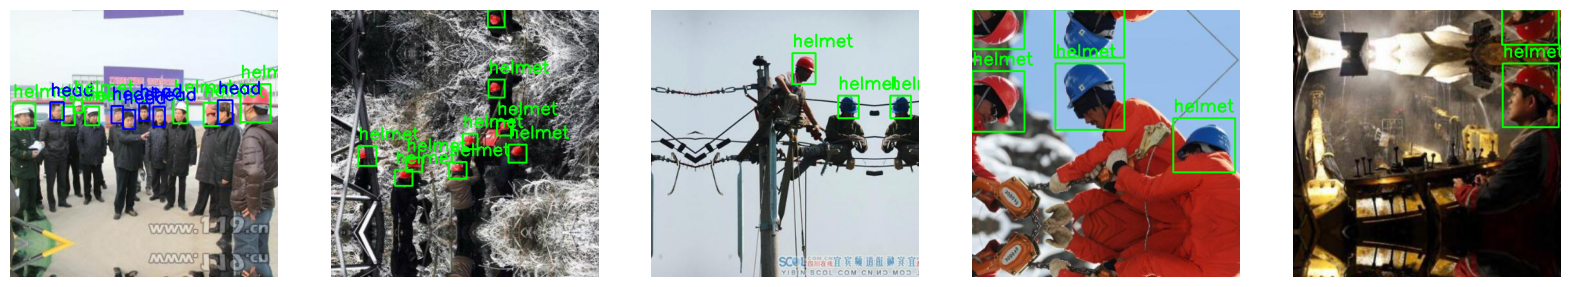

In [7]:
# Load and visualize raw data
images, annotations, class_names = load_dataset("Dataset/images", "Dataset/annotations")
plot_images(images, annotations, class_names)

In [8]:
#Train-Val-Test Split with Visualization
def split_data(images, annotations, test_size=0.2, val_size=0.2):
    # First split: train+val vs test
    X_train, X_test, y_train, y_test = train_test_split(
        images, annotations, test_size=test_size, random_state=42)
    
    # Second split: train vs val
    val_size_adj = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size_adj, random_state=42)
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

In [9]:
# Split and visualize
train_data, val_data, test_data = split_data(images, annotations)
print("Train:", len(train_data[0]), "Val:", len(val_data[0]), "Test:", len(test_data[0]))

Train: 3000 Val: 1000 Test: 1000



Train Samples:


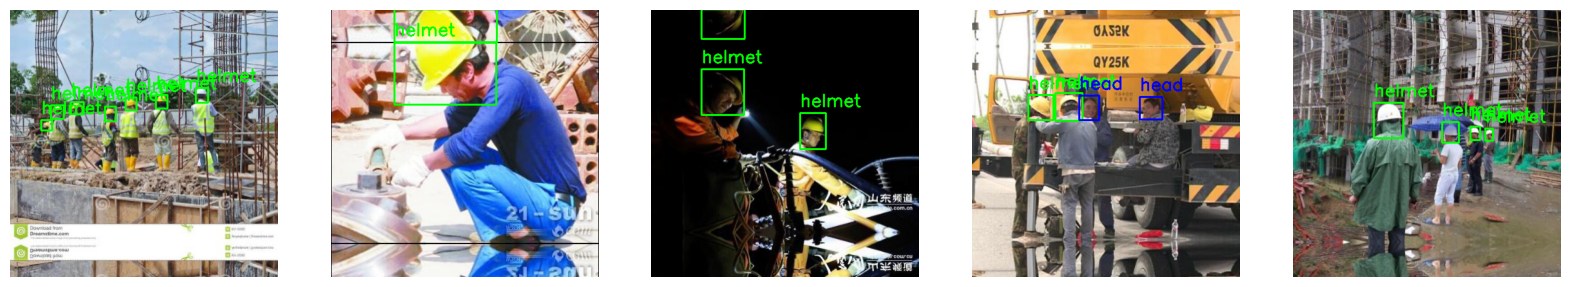


Validation Samples:


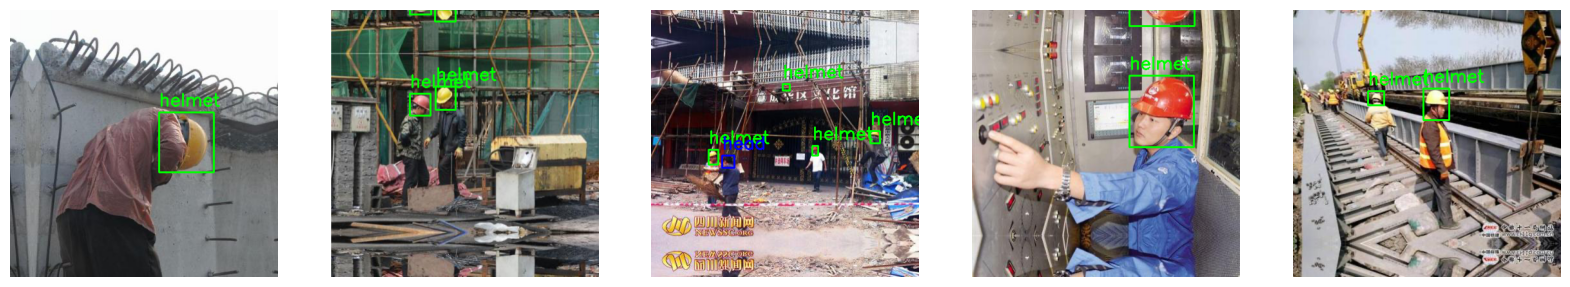


Test Samples:


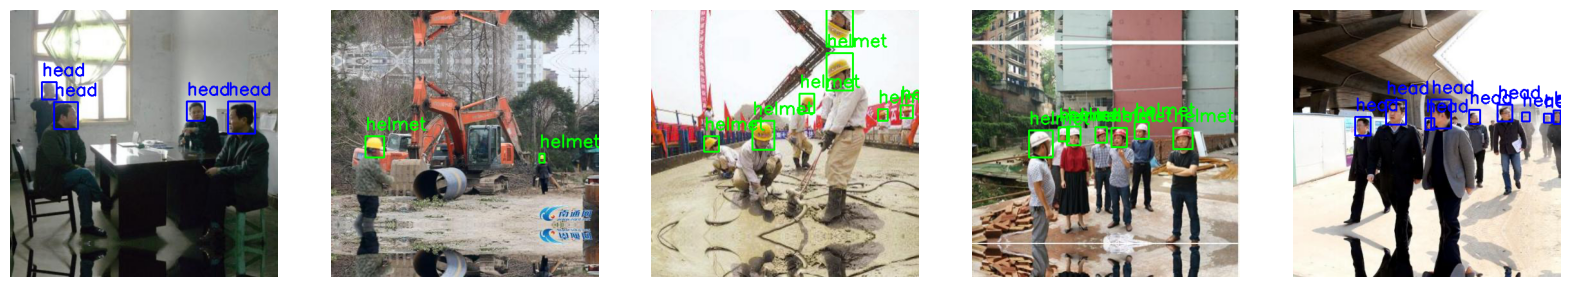

In [10]:
print("\nTrain Samples:")
plot_images(train_data[0], train_data[1], class_names)
print("\nValidation Samples:")
plot_images(val_data[0], val_data[1], class_names)
print("\nTest Samples:")
plot_images(test_data[0], test_data[1], class_names)

In [11]:
#Data Augmentation with BBox Awareness
class DataAugmenter:
    def __init__(self, target_size=(416, 416)):
        self.target_size = target_size
        
    def random_flip(self, image, bboxes):
        if np.random.rand() < 0.5:
            image = cv2.flip(image, 1)
            for i in range(len(bboxes)):
                _, xmin, ymin, xmax, ymax = bboxes[i]
                new_xmin = self.target_size[0] - xmax
                new_xmax = self.target_size[0] - xmin
                bboxes[i][1] = new_xmin
                bboxes[i][3] = new_xmax
        return image, bboxes
    
    def random_zoom(self, image, bboxes, min_zoom=0.8, max_zoom=1.2):
        zoom = np.random.uniform(min_zoom, max_zoom)
        h, w = image.shape[:2]

        try:
            # Resize the image
            new_h, new_w = int(h * zoom), int(w * zoom)
            resized = cv2.resize(image, (new_w, new_h))

            # Handle zoom-in (cropping)
            if zoom > 1.0:
                start_x = max(0, (new_w - w) // 2)
                start_y = max(0, (new_h - h) // 2)
                end_x = start_x + w
                end_y = start_y + h
                resized = resized[start_y:end_y, start_x:end_x]

                # Adjust bounding boxes
                for i in range(len(bboxes)):
                    bboxes[i][1] = (bboxes[i][1] * zoom) - start_x
                    bboxes[i][3] = (bboxes[i][3] * zoom) - start_x
                    bboxes[i][2] = (bboxes[i][2] * zoom) - start_y
                    bboxes[i][4] = (bboxes[i][4] * zoom) - start_y

            # Handle zoom-out (padding)
            else:
                delta_w = w - new_w
                delta_h = h - new_h
                top = delta_h // 2
                bottom = delta_h - top
                left = delta_w // 2
                right = delta_w - left

                resized = cv2.copyMakeBorder(resized, 
                                            top, bottom, 
                                            left, right, 
                                            cv2.BORDER_CONSTANT)

                # Adjust bounding boxes
                for i in range(len(bboxes)):
                    bboxes[i][1] = (bboxes[i][1] * zoom) + left
                    bboxes[i][3] = (bboxes[i][3] * zoom) + left
                    bboxes[i][2] = (bboxes[i][2] * zoom) + top
                    bboxes[i][4] = (bboxes[i][4] * zoom) + top

            # Ensure final size matches target
            final = cv2.resize(resized, (w, h))

            # Scale bounding boxes to original dimensions
            scale_x = w / new_w if zoom < 1 else 1.0
            scale_y = h / new_h if zoom < 1 else 1.0

            # Modify the final scaling step
            for i in range(len(bboxes)):
                bboxes[i][1] = int(np.clip(bboxes[i][1] * scale_x, 0, w-1))
                bboxes[i][3] = int(np.clip(bboxes[i][3] * scale_x, 0, w-1))
                bboxes[i][2] = int(np.clip(bboxes[i][2] * scale_y, 0, h-1))
                bboxes[i][4] = int(np.clip(bboxes[i][4] * scale_y, 0, h-1))            
                
            return final, bboxes
    
        except Exception as e:
            print(f"Zoom augmentation failed: {e}")
            return image.copy(), [b.copy() for b in bboxes]
    
    def augment(self, image, bboxes):
        image, bboxes = self.random_flip(image, bboxes)
        image, bboxes = self.random_zoom(image, bboxes)
        # Add post-augmentation validation
        validated_bboxes = []
        for bbox in bboxes:
            validated_bboxes.append(
                validate_box(bbox, 
                             img_width=image.shape[1], 
                             img_height=image.shape[0])
            )
        return image, validated_bboxes

Augmented Samples:


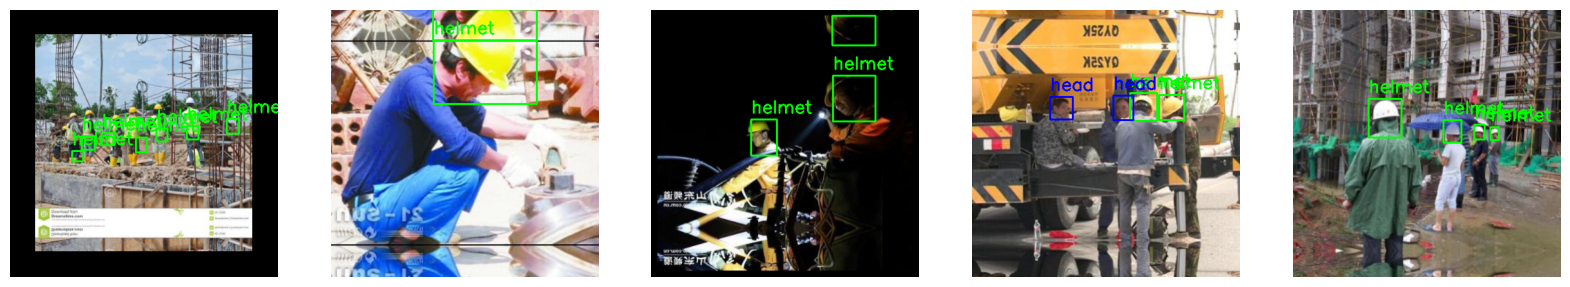

In [12]:
# Testing augmentation
augmenter = DataAugmenter()
aug_images, aug_bboxes = [], []

for img, bboxes in zip(train_data[0][:5], train_data[1][:5]):
    aug_img, aug_bbox = augmenter.augment(img.copy(), [b.copy() for b in bboxes])
    aug_images.append(aug_img)
    aug_bboxes.append(aug_bbox)

print("Augmented Samples:")
plot_images(aug_images, aug_bboxes, class_names)

In [13]:
# Data Generator (Updated)
class DetectionDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, images, annotations, batch_size=8, augment=False):
        self.images = images
        self.annotations = annotations
        self.batch_size = batch_size
        self.augment = augment
        self.augmenter = DataAugmenter()
        
        # Calculate maximum objects in the dataset
        self.max_objects = max(len(bboxes) for bboxes in annotations)
        print(f"Maximum objects per image: {self.max_objects}")
        
    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_images = []
        batch_bboxes = []
        batch_classes = []
        
        for i in range(idx*self.batch_size, (idx+1)*self.batch_size):
            if i >= len(self.images): break
            
            img = self.images[i]
            bboxes = self.annotations[i]
            
            if self.augment:
                img, bboxes = self.augmenter.augment(img.copy(), bboxes.copy())
            
            # Normalize image
            img = img / 255.0
            
            # Convert annotations to output format
            classes = np.array([b[0] for b in bboxes], dtype=np.int32)
            boxes = np.array([b[1:] for b in bboxes], dtype=np.float32)
            
            # Validation checks
            assert boxes.shape[1] == 4, "Boxes should have 4 coordinates"
            assert classes.shape[0] == boxes.shape[0], "Mismatch between class and box counts"
            
            batch_images.append(img)
            batch_classes.append(classes)
            batch_bboxes.append(boxes)
        
        # Pad sequences to fixed length
        padded_classes = []
        padded_boxes = []
        
        for cls, boxes in zip(batch_classes, batch_bboxes):
            pad_count = self.max_objects - len(cls)
            
            padded_classes.append(
                np.pad(cls, (0, pad_count), 
                mode='constant', 
                constant_values=-1)
            )
            
            padded_boxes.append(
                np.pad(boxes, [(0, pad_count), (0, 0)], 
                mode='constant', 
                constant_values=0)
            )
        
        return np.array(batch_images), {
            'class_output': np.array(padded_classes),
            'box_output': np.array(padded_boxes)
        }

In [14]:
# Create generators after calculating max_objects
train_gen = DetectionDataGenerator(train_data[0], train_data[1], augment=True)
val_gen = DetectionDataGenerator(val_data[0], val_data[1])
test_gen = DetectionDataGenerator(test_data[0], test_data[1])

Maximum objects per image: 53
Maximum objects per image: 68
Maximum objects per image: 58


In [15]:
# Visualize generator output
sample_batch = train_gen[0]

# Convert images to proper format
display_images = (sample_batch[0] * 255).astype(np.uint8)  # Convert to uint8

# Convert boxes to proper format
display_boxes = [[(c,) + tuple(b.astype(int))  # Convert coordinates to integers
                for c, b in zip(cls, boxes)] 
               for cls, boxes in zip(sample_batch[1]['class_output'], 
                                   sample_batch[1]['box_output'])]

print("Batch shapes:", sample_batch[0].shape, 
      sample_batch[1]['class_output'].shape, 
      sample_batch[1]['box_output'].shape)

plot_images(display_images, display_boxes, class_names)

Batch shapes: (8, 416, 416, 3) (8, 53) (8, 53, 4)


KeyError: -1

<Figure size 2000x1000 with 0 Axes>